Loading image from: 1.jpg
Image shape: (299, 299)


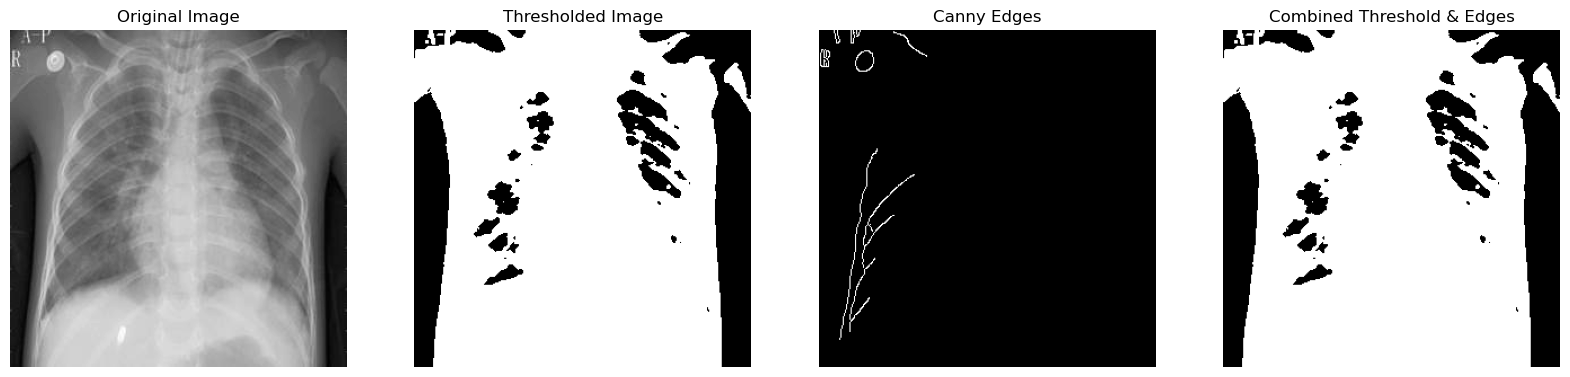

Edge detection and thresholding completed. Check the output images.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_lung_cancer(image_path, threshold_value, canny_threshold1, canny_threshold2):
    # Print the image path for debugging
    print(f"Loading image from: {image_path}")

    # Read the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was loaded
    if image is None:
        print("Error: Could not load image.")
        return

    # Print image shape to confirm loading
    print("Image shape:", image.shape)

    # Preprocess the image (optional)
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Thresholding: Convert to binary image
    _, thresholded = cv2.threshold(blurred, threshold_value, 255, cv2.THRESH_BINARY)

    # Perform Canny edge detection
    edges = cv2.Canny(blurred, threshold1=canny_threshold1, threshold2=canny_threshold2)

    # Combine the thresholded image with the edges (overlay them)
    combined = cv2.bitwise_or(thresholded, edges)

    # Display the original, thresholded, edge-detected, and combined images for comparison
    plt.figure(figsize=(20, 6))

    # Original image
    plt.subplot(1, 4, 1)
    plt.title('Original Image')
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    # Thresholded image
    plt.subplot(1, 4, 2)
    plt.title('Thresholded Image')
    plt.imshow(thresholded, cmap='gray')
    plt.axis('off')

    # Canny edge detection
    plt.subplot(1, 4, 3)
    plt.title('Canny Edges')
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    # Combined image (Threshold + Canny Edges)
    plt.subplot(1, 4, 4)
    plt.title('Combined Threshold & Edges')
    plt.imshow(combined, cmap='gray')
    plt.axis('off')

    plt.show()

    # Save the results to verify output
    cv2.imwrite('thresholded_output.jpg', thresholded)
    cv2.imwrite('edges_output.jpg', edges)
    cv2.imwrite('combined_output.jpg', combined)

    print("Edge detection and thresholding completed. Check the output images.")

# Example usage
image_path = '1.jpg'  # Make sure this file exists and is in the correct path
threshold_value = 100  # Adjust based on your image
canny_threshold1 = 50  # First threshold for Canny edge detection
canny_threshold2 = 150  # Second threshold for Canny edge detection

detect_lung_cancer(image_path, threshold_value, canny_threshold1, canny_threshold2)
